# Encontro 3 - Insper AI
# Introdução a Redes Neurais

---
*Autor: Thomas Kassabian - Diretor da Insper AI*  
*Colaboradores: -*  
*Atualizado em: 09/2025*  

---

O objetivo desta atividade é compreender a arquitetura e o funcionamento interno de uma **Rede Neural (Multilayer Perceptron - MLP)**, implementando manualmente o processo de **Forward Propagation** usando apenas NumPy em um dataset realista (Fashion MNIST).

### Contexto
Anteriormente, exploramos a Regressão Logística - um modelo linear que consegue classificar apenas dados linearmente separáveis. Agora daremos o próximo passo: **Redes Neurais**, que podem aprender padrões complexos e não-lineares nos dados.

### Etapas
1. Introdução ao neurônio artificial moderno e Funções de Ativação
2. Arquitetura de uma Rede Neural (MLP)
3. O processo de inferência (Forward Propagation)
4. Previsões e Avaliação
5. Comparação com TensorFlow/Keras
6. Conclusão

### Descrição do Dataset
O dataset **Fashion MNIST** é uma coleção de imagens de roupas em escala de cinza, com 60.000 imagens de treinamento e 10.000 imagens de teste. Cada imagem tem 28x28 pixels e pertence a uma das 10 categorias de roupas, como camisetas, calças, sapatos, etc.

É um dataset muito utilizado para testar modelos de ML, pois é uma alternativa mais desafiadora ao clássico MNIST de dígitos manuscritos.

O objetivo é classificar cada peça de roupa corretamente com base na imagem.

---

## Carregando dados e bibliotecas

Nessa atividade, usaremos as seguintes bibliotecas:
- **pandas**: Biblioteca para manipulação e análise de dados estruturados.
- **numpy**: Biblioteca para computação numérica eficiente.
- **tensorflow/keras**: Usaremos apenas para carregar o dataset Fashion MNIST.
- **matplotlib**: Biblioteca para visualização de dados.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregar os dados (como você já fez)
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

2025-09-16 19:22:56.139486: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-16 19:22:56.139872: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-16 19:22:56.181379: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-16 19:22:57.136446: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

### Visualizando uma imagem do dataset
A imagem abaixo mostra alguns exemplos de imagens do dataset Fashion MNIST e suas respectivas classes.

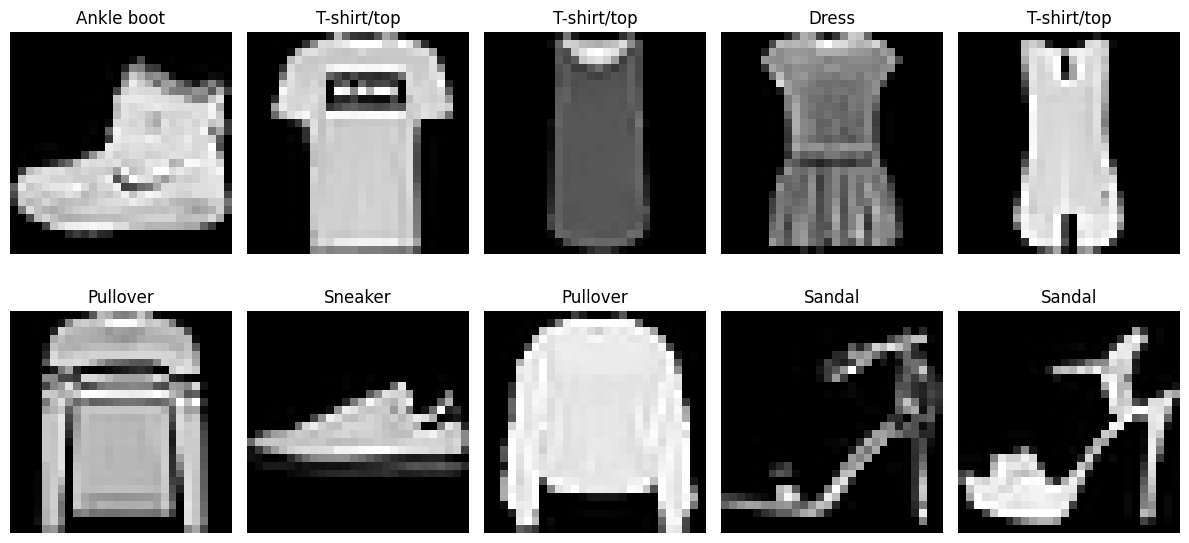

In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f'{class_names[y_train[i]]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 1. Introdução ao Neurônio Artificial Moderno e Funções de Ativação

### Motivação: a limitação dos modelos lineares
Modelos lineares, como a Regressão Logística, são limitados na sua capacidade de capturar padrões complexos nos dados. Eles funcionam bem quando as classes são linearmente separáveis. No caso da Regressão Logística, como vimos anteriormente, o modelo tenta encontrar uma fronteira de decisão **LINEAR** que separa as classes (reta em 2D ou plano em 3D).

#### O problema: dados não linearmente separáveis
Muitos problemas do mundo real envolvem dados que não são linearmente separáveis. Um exemplo clássico é o problema XOR (exclusive OR), onde os pontos de diferentes classes não podem ser separados por uma linha reta.
<div align="center">
<img src="https://miro.medium.com/max/1400/1*Tc8UgR_fjI_h0p3y4H9MwA.png" alt="Linear vs Non-linear" width="600"/>
<p><em>Exemplos de dados não-linearmente separáveis - Problema XOR</em></p>
</div>

À esquerda, estão os casos do AND e OR, onde as 2 possibilidades de saída (0 e 1) podem ser separadas por uma linha reta. No entanto, à direita, no caso do XOR, essa separação não é possível por uma linha reta. Isso ilustra a limitação dos modelos lineares.

Além disso outros exemplos de dados não-linearmente separáveis incluem:
1. **Círculos concêntricos**: Uma classe no centro, outra em volta
2. **Espirais**: Classes entrelaçadas em padrões curvos
3. **Imagens complexas**: Como distinguir entre diferentes peças de roupa no Fashion-MNIST

Daí surge a necessidade de modelos mais complexos, como as Redes Neurais, que podem aprender fronteiras de decisão não-lineares, mas como?

### O neurônio artificial moderno
A **Regressão Logística** que você implementou no encontro anterior é, essencialmente, um **neurônio artificial moderno**. Vamos fazer essa conexão explícita:

**Regressão Logística (nossa implementação):**
1. Entrada linear: $z = \mathbf{w}^T \cdot \mathbf{x} + b$
2. Função de ativação: $\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$ (sigmoide)
3. Saída: Probabilidade entre 0 e 1

**Neurônio Artificial:**
1. **Soma ponderada**: $z = \sum_{i} w_i \cdot x_i + b$ (mesmo que antes!)
2. **Função de ativação**: $a = f(z)$ (sigmoide ou outras)
3. **Saída**: Valor ativado $a$

<div align="center">
<img src="https://miro.medium.com/max/1838/1*n6sJ4yZQzwKL9wnF5wnVNg.png" alt="Neuronio" width="500"/>
<p><em>Lógica de inferência de um neurônio artificial</em></p>
</div>

**A única diferença é conceitual**: em vez de interpretar diretamente como "probabilidade de classe", interpretamos como "ativação de um neurônio" que pode ser passada para outros neurônios.

#### Por que "Neurônio"?
O nome vem da inspiração biológica. Assim como um neurônio no cérebro recebe sinais de outros neurônios, processa esses sinais e envia um novo sinal, o neurônio artificial faz o mesmo com dados numéricos.

### Funções de ativação

A função de ativação é crucial para introduzir **não-linearidade** no modelo. Sem ela, uma rede neural composta apenas por camadas lineares seria equivalente a uma única camada linear, como visto em aula, limitando severamente sua capacidade de modelar dados complexos.

#### Função Sigmoide
A função sigmoide é uma das funções de ativação mais antigas e comuns. Como já vimos anteriormente, ela mapeia qualquer valor real para o intervalo (0, 1), o que a torna útil para problemas de classificação binária.
$$\sigma(z) = \frac{1}{1 + e^{-z}}
$$

#### Função ReLU (Rectified Linear Unit)
A função ReLU é atualmente a mais popular em redes neurais profundas. Ela é definida como:
$$\text{ReLU}(z) = \max(0, z)
$$
Isso significa que qualquer valor negativo é mapeado para 0, enquanto valores positivos são mantidos. A ReLU é computacionalmente eficiente e ajuda a mitigar alguns problemas associados à sigmoide, como o desaparecimento do gradiente (chegaremos lá).

<div align="center">
<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250129162127770664/Relu-activation-function.png" width="600"/>
<p><em>Função de ativação ReLU</em></p>
</div>

A saída da ReLU, chamada de logit, é não-linear, permitindo que a rede aprenda padrões complexos.

### Implementação
Tivemos bastante teoria até agora, tudo para chegar em uma implementação simples de uma função de ativação ReLU. Mas é vital que você entenda de onde surge a necessidade dela.

#### Tarefa: implemente a função ReLU em Python usando NumPy.
A função deve receber um valor real ou um array de shape (n,) e retornar um novo valor real ou array onde cada elemento é o máximo entre 0 e o valor original.
$$\text{ReLU}(z) = \max(0, z)
$$

**Dica**: considere usar a função `np.maximum`.

In [3]:
def relu(z):
    """
    Args:
    z: array de shape (n,)
    """
    return np.maximum(0, z)

# Testando a função ReLU (Rode a célula)
test_array = np.array([-3, -1, 0, 1, 3])
print("Array Input:", test_array)
print("ReLU Output:", relu(test_array))

test_value = -5
print("\nValue Input:", test_value)
print("ReLU Output:", relu(test_value))

Array Input: [-3 -1  0  1  3]
ReLU Output: [0 0 0 1 3]

Value Input: -5
ReLU Output: 0


## 2. Arquitetura de uma Rede Neural (MLP)

### O que é um MLP (Multilayer Perceptron)?

Um **MLP** é uma rede neural formada por múltiplas camadas de neurônios totalmente conectados. "Totalmente conectado" significa que cada neurônio de uma camada se conecta a **todos** os neurônios da camada seguinte.

### Anatomia de um MLP

**1. Camada de Entrada (Input Layer)**
- Não processa dados, apenas recebe as features
- Cada neurônio representa uma feature (pixel, no caso de imagens)

**2. Camadas Ocultas (Hidden Layers)**
- Onde acontece o "aprendizado" real
- Em redes neurais modernas, usam ReLU como função de ativação
- Cada camada pode ter qualquer número de neurônios

**3. Camada de Saída (Output Layer)**
- Produz o resultado final
- O tamanho e função de ativação dependem do tipo de problema (classificação binária, multiclasse, regressão)

### A saída: Softmax para classificação multiclasse
Para problemas de classificação multiclasse, a camada de saída geralmente usa a função **Softmax**, que converte os logits em probabilidades para cada classe.
$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$

Pense no seguinte fluxo, imaginando uma rede que a última camada oculta em 64 neurônios e a camada de saída com 10 neurônios (para 10 classes):
1. **Saída da última camada oculta**: será um vetor de 64 elementos (as ativações dos 64 neurônios)

2. **Cálculo dos logits**: cada um dos 10 neurônios na camada de saída receberá um vetor de 64 elementos, calculará sua soma ponderada (com pesos e bias) e produzirá um logit (valor real chamado de score)

3. **Aplicação do Softmax**: os 10 logits serão passados pela função Softmax, resultando em um vetor de 10 probabilidades que somam 1, onde cada valor representa a probabilidade da imagem pertencer a cada classe.



### Implementação
Implemente a função softmax em Python usando NumPy. A função deve receber um array de logits e retornar um array de probabilidades.

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}
$$

**Dicas**:
- Use `np.exp` para calcular a exponencial.
- Use `np.sum` para calcular a soma dos exponenciais.
- Adicione uma pequena constante (ex: 1e-9) ao denominador para evitar divisão por zero.
- Estabilize a entrada z, subtraindo o valor máximo de z antes de aplicar a exponencial, para evitar overflow.

In [4]:
def softmax(z):
    """
    Args:
    z: array de shape (n,)
    """
    z_estavel = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_estavel)
    soma_exp_z = np.sum(exp_z, axis=1, keepdims=True)
    return exp_z / (soma_exp_z + 1e-15)

# Testando a função Softmax (Rode a célula)
# Array de teste original (1D, shape (3,))
test_array_1d = np.array([1.0, 2.0, 3.0])

# Corrigindo o teste para simular um lote de 1 amostra (2D, shape (1, 3))
test_array_2d = test_array_1d.reshape(1, -1)

print("Array Input (corrigido):", test_array_2d)
print("Shape do Input:", test_array_2d.shape)

# Agora a função softmax funcionará, pois o input tem o axis=1
print("Softmax Output:", softmax(test_array_2d))

Array Input (corrigido): [[1. 2. 3.]]
Shape do Input: (1, 3)
Softmax Output: [[0.09003057 0.24472847 0.66524096]]


## 3. O processo de inferência (Forward Propagation)

### O que é Forward Propagation?

**Forward Propagation** (Propagação Direta) é o processo pelo qual uma entrada percorre toda a rede neural, camada por camada, até produzir uma saída final. É literalmente como os dados "fluem para frente" através da rede.

### Como os Neurônios se Conectam

Matematicamente, cada camada realiza uma **transformação linear seguida de ativação**:

$$\mathbf{z}^{[l]} = \mathbf{W}^{[l]} \cdot \mathbf{a}^{[l-1]} + \mathbf{b}^{[l]}$$
$$\mathbf{a}^{[l]} = f(\mathbf{z}^{[l]})$$

Onde:
- $\mathbf{W}^{[l]}$: Matriz de pesos da camada $l$
- $\mathbf{b}^{[l]}$: Vetor de bias da camada $l$
- $\mathbf{a}^{[l-1]}$: Ativações da camada anterior
- $f()$: Função de ativação (ReLU, Softmax, etc.)

Pense nisso como o seguinte:
1. Cada neurônio calcula uma soma ponderada das entradas (com pesos e bias)
2. Aplica a função de ativação para introduzir não-linearidade
3. Passa a ativação para a próxima camada -> Cada saída, de cada neurônio, torna-se uma entrada para todos os neurônios na próxima camada. Dessa forma, todos os neurônios estão interconectados (totalmente conectados).

#### O Processo Passo a Passo

Vamos rastrear como uma imagem de 28×28 pixels passa pela nossa rede:

**Passo 1: Preparação da Entrada**
```
Entrada original: Matriz 28×28 (imagem)
Entrada processada: Vetor 784×1 (flatten + normalização)
```

**Passo 2: Primeira Camada Oculta**
```
z₁ = W₁ × entrada + b₁     # Transformação linear
a₁ = ReLU(z₁)              # Função de ativação
```

**Passo 3: Segunda Camada Oculta**
```
z₂ = W₂ × a₁ + b₂          # Usa saída da camada anterior
a₂ = ReLU(z₂)              # Função de ativação
```

**Passo 4: Camada de Saída**
```
z₃ = W₃ × a₂ + b₃          # Transformação final
a₃ = Softmax(z₃)           # Probabilidades das classes
```

#### Dimensões das Matrizes

Para nossa arquitetura (784 → 128 → 64 → 10):

- **W₁**: 128 × 784 (cada linha = pesos de um neurônio)
- **b₁**: 128 × 1 (um bias por neurônio)
- **W₂**: 64 × 128
- **b₂**: 64 × 1
- **W₃**: 10 × 64
- **b₃**: 10 × 1

#### Representação Matemática Completa

$$\mathbf{a}^{[0]} = \text{entrada normalizada}$$
$$\mathbf{z}^{[1]} = \mathbf{W}^{[1]} \mathbf{a}^{[0]} + \mathbf{b}^{[1]}$$
$$\mathbf{a}^{[1]} = \text{ReLU}(\mathbf{z}^{[1]})$$
$$\mathbf{z}^{[2]} = \mathbf{W}^{[2]} \mathbf{a}^{[1]} + \mathbf{b}^{[2]}$$
$$\mathbf{a}^{[2]} = \text{ReLU}(\mathbf{z}^{[2]})$$
$$\mathbf{z}^{[3]} = \mathbf{W}^{[3]} \mathbf{a}^{[2]} + \mathbf{b}^{[3]}$$
$$\mathbf{a}^{[3]} = \text{Softmax}(\mathbf{z}^{[3]})$$

**Resultado**: $\mathbf{a}^{[3]}$ é um vetor de 10 probabilidades que somam 1!

### Implementação

#### Primeiro problema: como usar os dados de imagem?

A princípio, imagens, em escala de cinza, são representadas como matrizes 2D (altura x largura). No entanto, a maioria dos modelos de ML, incluindo MLPs, espera que os dados sejam fornecidos em formato vetorial (1D).

Para resolver isso, precisamos "achatar" cada imagem 2D em um vetor 1D. Como as imagens são de 28x28 pixels, cada uma deve ser convertida em um vetor de 784 (28x28) elementos.

#### Tarefa: transforme as imagens 2D em vetores 1D usando NumPy.
Gere dois novos arrays `X_train_flat` e `X_test_flat` com as imagens achatadas.

**Dicas**:
- Use a função `reshape` do NumPy.
- A função `reshape` pode receber `-1` como um dos argumentos para inferir automaticamente a dimensão correta.

In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Dimensões do conjunto de treino: {X_train_flat.shape}")
print(f"Dimensões do conjunto de teste: {X_test_flat.shape}")

Dimensões do conjunto de treino: (60000, 784)
Dimensões do conjunto de teste: (10000, 784)


### Agora sim, vamos implementar o Forward Propagation!

#### Tarefa: implemente o Forward Propagation em Python usando NumPy.
A função deve receber:
- `img_batch`: array de shape (n_amostras, n_features) com as entradas (um batch de imagens achatadas)
- `weights`: lista de matrizes com os pesos de cada camada
- `biases`: lista de vetores com os biases de cada camada
E retornar:
- `output`: array de shape (n_classes,) com as probabilidades de cada classe

In [6]:
def forward_propagation(X, weights, biases):
    """
    Args:
    X: array de shape (n_amostras, n_features_entrada) com as entradas
    weights: lista de matrizes com os pesos de cada camada [W1, W2, ...]
    biases: lista de vetores com os biases de cada camada [b1, b2, ...]
    """
    # A entrada para a primeira camada é o próprio dataset
    a = X / 255.0

    # Loop sobre as camadas ocultas (todas, exceto a última)
    for i in range(len(weights) - 1):
        W = weights[i]
        b = biases[i]
        
        # Transformação linear. Note a ordem: a @ W.T
        # Shapes: (n_amostras, n_feats_in) @ (n_feats_in, n_feats_out) -> (n_amostras, n_feats_out)
        z = np.dot(a, W.T) + b.T
        
        # Ativação ReLU
        a = relu(z)

    # Processamento da camada de saída (a última da lista)
    W_saida = weights[-1]
    b_saida = biases[-1]

    z_saida = np.dot(a, W_saida.T) + b_saida.T

    # Ativação final com Softmax
    output = softmax(z_saida)

    return output

## 4. Previsões e Avaliação

### Previsões
Após implementar o Forward Propagation, podemos usar a saída da rede para fazer previsões. A previsão para cada amostra é a classe com a maior probabilidade.

Rode a célula abaixo para carregar os pesos e biases pré-treinados:

In [7]:
try:
    W1 = np.load('pesos/w1.npy')
    b1 = np.load('pesos/b1.npy')
    W2 = np.load('pesos/w2.npy')
    b2 = np.load('pesos/b2.npy')
    W3 = np.load('pesos/w3.npy')
    b3 = np.load('pesos/b3.npy')
    
    W = [W1, W2, W3]
    b = [b1, b2, b3]

    print("Pesos e biases carregados com sucesso!")
    print(f"Formato de W1: {W1.shape}")
    print(f"Formato de W2: {W2.shape}")
    print(f"Formato de W3: {W3.shape}")

except FileNotFoundError:
    print("Erro: A pasta 'pesos/' com os arquivos .npy não foi encontrada.")
    print("Certifique-se de ter baixado e colocado a pasta no mesmo diretório deste notebook.")

Pesos e biases carregados com sucesso!
Formato de W1: (128, 784)
Formato de W2: (64, 128)
Formato de W3: (10, 64)


#### Tarefa: implemente a previsão e a avaliação

Use a função de Forward Propagation para obter as probabilidades e depois determine a classe prevista para cada imagem no conjunto de teste. Imprima a acurácia do modelo.

**Dicas**:
- Use `np.argmax` para encontrar o índice da classe com a maior probabilidade.
- Use a função de Forward Propagation que você implementou anteriormente.

In [8]:
# Fazer previsões no conjunto de teste
predictions = forward_propagation(X_test_flat, W, b)

# Converter as probabilidades em classes previstas
predicted_classes = np.argmax(predictions, axis=1)

print("Classes previstas:", predicted_classes)

# Avaliar a acurácia
accuracy = np.mean(predicted_classes == y_test)
print(f"Acurácia no conjunto de teste: {accuracy * 100:.2f}%")

Classes previstas: [9 2 1 ... 8 1 5]
Acurácia no conjunto de teste: 82.18%


## 5. Comparação com TensorFlow/Keras

A célula abaixo roda o mesmo modelo, implementado com um framework de alto nível (TensorFlow/Keras), para validar que nossa implementação manual está correta.

In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Criar o modelo com a mesma arquitetura
model = Sequential([
    Flatten(input_shape=(28, 28)),  # Camada de entrada (flatten)
    Dense(128, activation='relu'),  # Primeira camada oculta
    Dense(64, activation='relu'),   # Segunda camada oculta
    Dense(10, activation='softmax') # Camada de saída
])

# Configurar os pesos e biases manualmente
model.layers[1].set_weights([W1.T, b1.flatten()])
model.layers[2].set_weights([W2.T, b2.flatten()])
model.layers[3].set_weights([W3.T, b3.flatten()])

# Compilar o modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Avaliar o modelo no conjunto de teste
test_loss, test_accuracy = model.evaluate(X_test / 255.0 , y_test, verbose=0)
print(f"Acurácia no conjunto de teste: {test_accuracy * 100:.2f}%")

/home/thomaskmk/repositories/insper-ai/encontros/insper-ai-mlp-3-mlp/.venv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2025-09-16 19:23:01.441854: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Acurácia no conjunto de teste: 82.18%


## 6. Conclusão

Neste notebook, implementamos manualmente o processo de inferência de um MLP, o **Forward Propagation**, utilizando apenas NumPy. O resultado foi validado contra uma implementação equivalente em um framework de alto nível, confirmando a correção do nosso código.

**Recapitulando:**

* **Anatomia do MLP:** A estrutura de uma rede foi detalhada, compreendendo o papel da **Camada de Entrada** (representando as features), das **Camadas Ocultas** (aprendendo representações complexas) e da **Camada de Saída** (produzindo o resultado final para o número de classes).

* **O Papel das Funções de Ativação:** A necessidade de **Funções de Ativação não-lineares (ReLU)** foi estabelecida como o componente que permite à rede aprender padrões complexos. A **Softmax** foi apresentada como a solução padrão para converter os scores brutos da camada de saída em uma distribuição de probabilidade multiclasse.

* **Forward Propagation Desmistificado:** O processo de "previsão" de uma rede neural foi esclarecido. Entendemos que ele é uma sequência determinística de operações de álgebra linear (`Wx + b`) seguidas pela aplicação das funções de ativação, propagando a informação da entrada até a saída.

* **Conexão Teoria-Código:** A relação direta entre a notação matemática de uma rede neural e sua implementação prática com operações de matrizes em NumPy foi solidificada.

**Próximos Passos:**

Até agora, trabalhamos com uma rede *pré-treinada*. Nós entendemos como uma rede **usa** seus pesos e biases para fazer uma previsão. A pergunta fundamental que permanece é: **como a rede aprende os valores ideais para esses parâmetros?**

É isso que exploraremos no próximo encontro: a **Função de Custo** (que mede o erro), o algoritmo de **Backpropagation** (que calcula como o erro se distribui pela rede) e os **Otimizadores** (como o Adam), que usam essa informação para ajustar os pesos iterativamente.